# Gaussian Physics Explained

This notebook shows how a local Gaussian ray captures wavefront physics and how common optical elements modify that local model.

**Sections**
- Propagation integral and the quadratic local model
- Interactive controls for the Gaussian ray parameters
- Worked examples: thin lens, aberrated lens, and half-edge aperture


## Propagation As A Kernel Integral

We model propagation between an input point $\mathbf{r}$ and output point $\mathbf{r}'$ with the scalar integral

$$U'(\mathbf{r}') = \iint_{\mathbb{R}^2} U(\mathbf{r})\,K_S(\mathbf{r}, \mathbf{r}')\,\mathrm{d}^2\mathbf{r}. $$

Here the kernel $K_S$ encodes an optical path $S(\mathbf{r},\mathbf{r}')$, so we are free to choose models beyond paraxial or free-space propagation. Each area element $\mathrm{d}^2\mathbf{r}$ contributes a tilted, curved complex patch that interferes with every output point.

To make the integral tractable we can:
- choose an input field $U(\mathbf{r})$ that admits a compact local description, and
- approximate the kernel $K_S$ with a local Taylor series about the same expansion point.

## Local Quadratic Wavefront Model

Let $\mathbf{r}_0 = (x_0, y_0)$ be the patch centre and write the field

$$U(\mathbf{r}) = A \exp\big( i k S(\mathbf{r}) \big).$$

Expanding the action to second order gives

$$S(\mathbf{r}) \approx S(\mathbf{r}_0) + \nabla S(\mathbf{r}_0)\cdot(\mathbf{r}-\mathbf{r}_0) + \tfrac{1}{2}(\mathbf{r}-\mathbf{r}_0)^\top H_S(\mathbf{r}_0)(\mathbf{r}-\mathbf{r}_0),$$

with gradient $\nabla S = (\partial_x S, \partial_y S)$ and Hessian

$$H_S = \begin{pmatrix}\partial_x^2 S & \partial_x\partial_y S\\\partial_y\partial_x S & \partial_y^2 S\end{pmatrix}_{\!\mathbf{r}_0}. $$

### Interpreting The Terms

- $\exp(ik S(\mathbf{r}_0))$: constant phase offset.
- $\exp(ik\nabla S\cdot(\mathbf{r}-\mathbf{r}_0))$: linear phase describing local tilt.
- $\exp(\tfrac{ik}{2}(\mathbf{r}-\mathbf{r}_0)^\top H_S (\mathbf{r}-\mathbf{r}_0))$: quadratic phase capturing local curvature or astigmatism.

## Connection To Gaussian Beam Notation

For paraxial Gaussian beams the quadratic term is commonly written using the complex curvature matrix $Q_{\text{inv}}$:

$$U(\mathbf{r}) = \exp\Big[ \tfrac{ik}{2}(\mathbf{r}-\mathbf{r}_0)^\top Q_{\text{inv}}(\mathbf{r}_0)(\mathbf{r}-\mathbf{r}_0) \Big].$$

Each entry combines curvature and confinement through the complex radius

$$ q = z - j z_R, \qquad \frac{1}{q(z)} = \frac{1}{R(z)} + j\frac{\lambda}{\pi W^2(z)}. $$

The real part $1/R(z)$ stores curvature while the imaginary part determines the waist $W(z)$.

### Worked Example: Thin Lens (Paraxial)

For a focal length $f$,

$$ S(\mathbf{r}) = \frac{x^2 + y^2}{2f} = \frac{\|\mathbf{r}\|^2}{2f}. $$

The gradient and Hessian are

$$ \nabla S = \frac{\mathbf{r}}{f}, \qquad H_S = \frac{1}{f} I_2, $$

so the Taylor expansion about $\mathbf{r}_0$ is exact and the quadratic coefficient matrix becomes $\tfrac{ik}{2f} I_2$.

### Updating The Gaussian Parameters

The kernel's local Taylor pieces simply add to the Gaussian action coefficients:

$$\begin{aligned} S'_{\text{const}} &= S_{\text{const}} + \Delta S_0, \\ \mathbf{S}'_{\text{lin}} &= \mathbf{S}_{\text{lin}} + \Delta \mathbf{S}_1, \\ S'_{\text{quad}} &= S_{\text{quad}} + \Delta S_2.\end{aligned}$$

where $\Delta S_0$, $\Delta \mathbf{S}_1$, and $\Delta S_2$ come from the kernel's Taylor expansion at $\mathbf{r}_0$. The remainder of the notebook applies these updates in code.


In [79]:
import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from matplotlib.widgets import Slider
from dataclasses import dataclass
from temgym_core.utils import FresnelPropagator1D
%matplotlib widget

@dataclass(frozen=True)
class GaussianRay1D:
    C: complex = 1+0j          # global amplitude+phase
    S1: complex = 0+0j         # linear action coeff
    S2: complex = 1j           # quadratic action coeff
    x0: float = 0.0            # expansion origin
    k: float = 1.0             # wavenumber

    def xi(self, x):
        """Local coordinate relative to expansion origin."""
        return jnp.asarray(x, dtype=float) - self.x0

    def action(self, x):
        xi = self.xi(x)
        return self.S1 * xi + 0.5 * self.S2 * xi * xi

    def field(self, x):
        return self.C * jnp.exp(1j * self.k * self.action(x))

    def amplitude(self, x):
        return jnp.abs(self.field(x))

    def intensity(self, x):
        psi = self.field(x)
        return jnp.abs(psi) ** 2

    def phase(self, x):
        return jnp.angle(self.field(x))

    # --- intensity-centre only ---
    def ray_position(self, eps: float = 1e-12) -> float:
        return self.x0 - self.S1.imag / (self.S2.imag + eps)

    def ray_slope(self, eps: float = 1e-12) -> float:
        xi = - self.S1.imag / (self.S2.imag + eps)
        p  = self.S1 + self.S2 * xi
        return p.real / self.k

    def intensity_center(self, eps: float = 1e-12) -> float:
        return self.ray_position(eps)

    def recenter_to_intensity(self, eps: float = 1e-12):
        x_c = self.ray_position(eps)
        return self.recenter(x_c)

    # --- exact recenter (to any x_c) ---
    def recenter(self, new_x0: float):
        delta = float(new_x0) - self.x0
        Cn = self.C * jnp.exp(1j * self.k * (self.S1*delta + 0.5*self.S2*delta*delta))
        S1n = self.S1 + self.S2 * delta
        return GaussianRay1D(C=Cn, S1=S1n, S2=self.S2, x0=float(new_x0), k=self.k)

    def propagate(self, A, B, C, D, L=0.0):
        # L is the physical propagation distance which we might still like to track
        # complex-cast (robust for symbolic A,B,C,D too)
        A = complex(A); B = complex(B); C = complex(C); D = complex(D)

        eps = 1e-12
        if abs(A) < eps and abs(B) < eps:
            raise ValueError("ABCD matrix is singular: A and B both zero.")

        if abs(B) < eps:
            den = A
            x0p = float((den * self.x0).real)
            S2p = (C + D * self.S2) / den    # curvature map (lens-like)
            S1p = (self.S1 + C * x0p) / den   # slope map with translated origin
            dS0 = 0.5 * C * self.x0 * x0p     # on-axis phase
            Cp = self.C * jnp.exp(-0.5 * jnp.log(den)) * jnp.exp(1j * self.k * (dS0 + L))
            return GaussianRay1D(C=Cp, S1=S1p, S2=S2p, x0=x0p, k=self.k)

        den = A + B * self.S2               # A + B S2
        S2p = (C + D * self.S2) / den    # curvature map
        S1p = self.S1 / den                 # slope map

        # Constant action from completing the square (x-independent):
        dS0 = -0.5 * B * (self.S1 * self.S1) / den

        # Use complex log for a continuous branch of the square root
        Cp = self.C * jnp.exp(-0.5 * jnp.log(den)) * jnp.exp(1j * self.k * (dS0 + L))

        return GaussianRay1D(C=Cp, S1=S1p, S2=S2p, x0=self.x0, k=self.k)

    # --- local phase and amplitude (intensity-centred) ---
    # Phase: φ(ξ) ≈ φ0 + φ1 ξ + 0.5 φ2 ξ^2
    def apply_local_phase(self, phi0=0.0, phi1=0.0, phi2=0.0):
        Cn  = self.C * jnp.exp(1j * self.k * phi0)
        return GaussianRay1D(C=Cn, S1=self.S1+phi1, S2=self.S2+phi2, x0=self.x0, k=self.k)

    # Amplitude: a(ξ) = exp(ℓ0 + ℓ1 ξ + 0.5 ℓ2 ξ^2)
    def apply_local_amplitude(self, ell0=0.0, ell1=0.0, ell2=0.0):
        Cn  = self.C * jnp.exp(ell0)
        # Fold amplitude into action as purely imaginary terms
        return GaussianRay1D(C=Cn,
                             S1=self.S1 - 1j*ell1/self.k,
                             S2=self.S2 - 1j*ell2/self.k,
                             x0=self.x0, k=self.k)

    # --- set from desired (x,u) at current x0 (intensity-centre convention) ---
    def with_ray(self, x: float, u: float):
        xi = float(x) - self.x0
        S1n = self.k*float(u) - self.S2*xi
        return GaussianRay1D(C=self.C, S1=S1n, S2=self.S2, x0=self.x0, k=self.k)
    

    @classmethod
    def from_gaussian(cls, 
                      x: float, 
                      dx: float, 
                      InitAmp: float = 1.0, 
                      InitPhase: float = 0.0,
                      BeamWaist: float = 1.0, 
                      RadiusOfCurvature: float = jnp.inf, 
                      k: float = 1.0):

        S1_real = k * dx # Real part of linear action is k * input slope
        S1_imag = 0.0 # Imaginary part of linear action = 0 for pure Gaussian
        S2_real = 0.0 if jnp.isinf(RadiusOfCurvature) else 1.0/RadiusOfCurvature  # Real part of quadratic action is related to radius of curvature
        S2_imag  = 1.0 / (2.0 * k * (BeamWaist**2)) # Imaginary part of quadratic action is related to beam waist

        S1 = complex(S1_real, S1_imag)
        S2 = complex(S2_real, S2_imag)
        C = InitAmp * jnp.exp(1j * InitPhase)
        return cls(C=C, S1=S1, S2=S2, x0=x, k=k)


## Interactive Ray Explorer

The next cell builds a small dashboard to manipulate a 1D Gaussian ray. Use the sliders to adjust amplitude, waist, curvature, and reference point while the plots update in real time.

Tips:
- The left plot shows intensity with the current envelope centre.
- The right plot shows the wrapped phase $\phi(x)$.
- Toggle *Lock x₀→x_c* to keep the reference point aligned with the intensity peak, or *Conserve peak* to keep the central amplitude fixed.


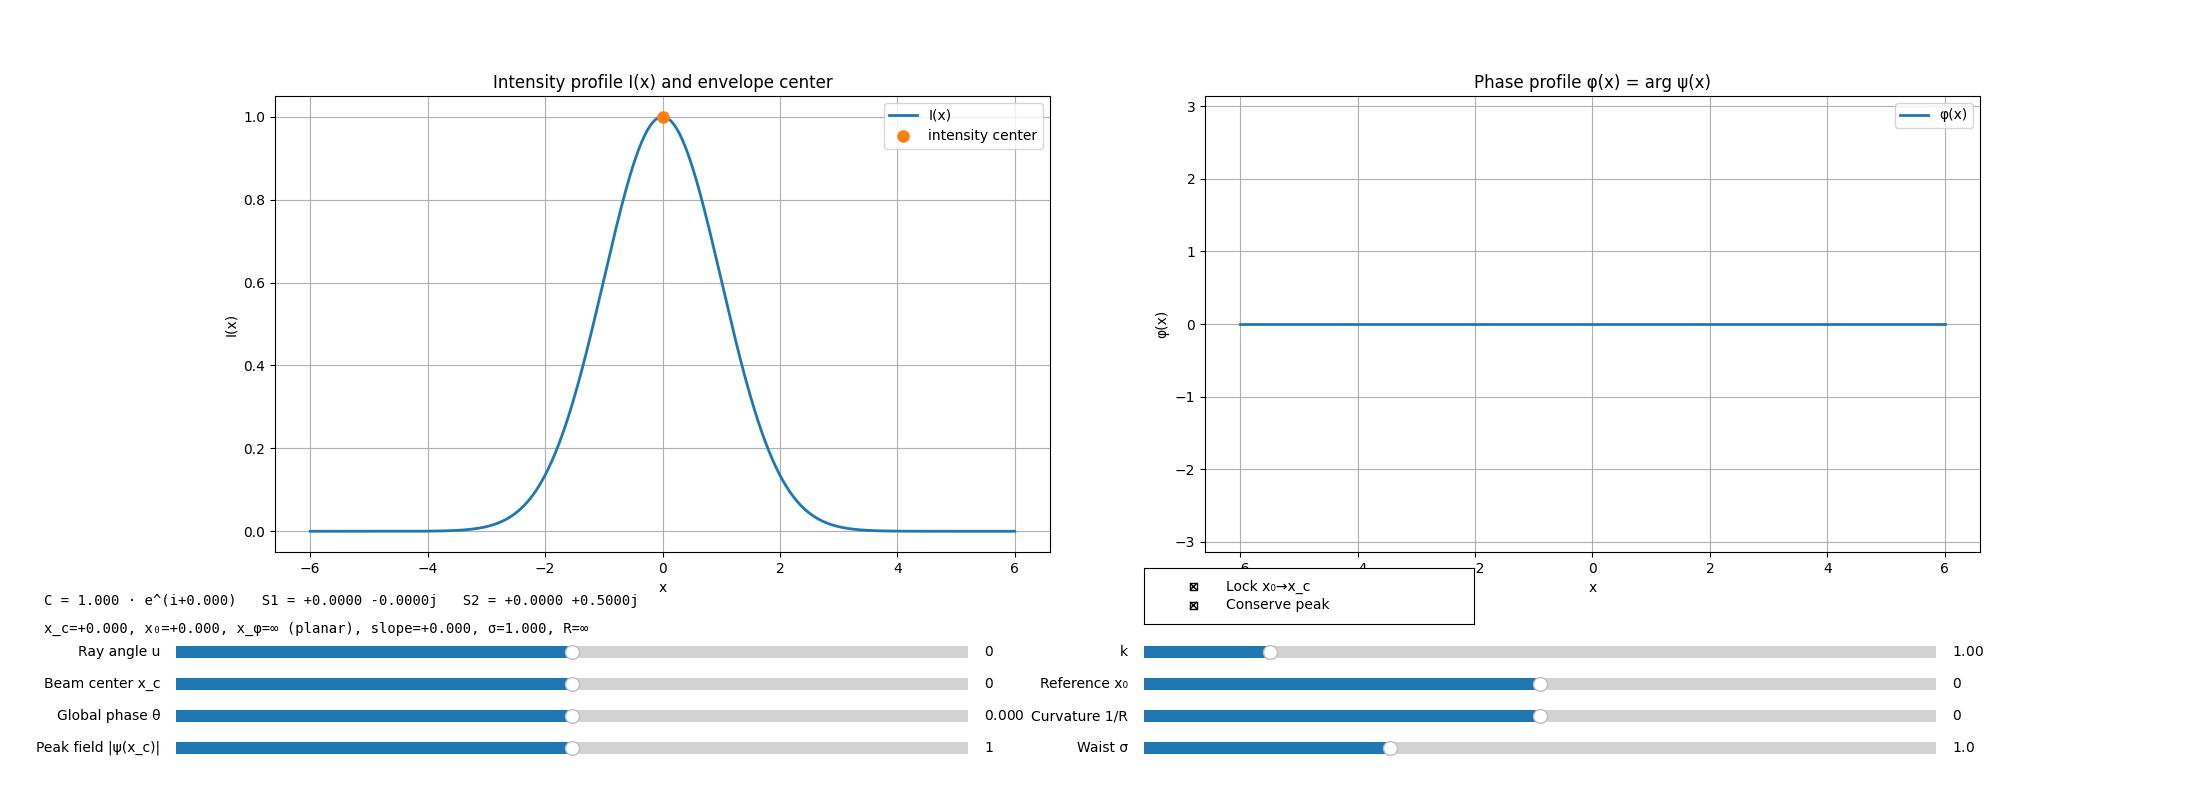

In [80]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.widgets import Slider

# --- assume your GaussianRay1D class (with from_gaussian) is already defined ---
# from dataclasses import dataclass
# jnp = np
# class GaussianRay1D: ... (your implementation with .from_gaussian)

# Helper: infer physical knobs from a ray (centered/uncentered both OK)
def infer_physical_from_ray(ray):
    x_c = ray.intensity_center()
    u   = ray.ray_slope()
    beta = float(np.imag(ray.S2))                              # Im(S2)
    k    = float(ray.k)
    sigma = np.sqrt(1.0 / (2.0 * k * max(beta, 1e-12)))        # width
    alpha = float(np.real(ray.S2))                              # Re(S2) = 1/R
    curv  = alpha
    theta = float(np.angle(ray.C))
    # peak field at center: |psi(x_c)| = |C| * exp(k b^2/(2 beta)), with b = Im(S1)
    b = float(np.imag(ray.S1))
    A_pk = float(np.abs(ray.C)) * np.exp(k * (b*b) / max(2.0*beta, 1e-12))
    return dict(x_c=x_c, u=u, sigma=sigma, curv=curv, theta=theta, A_pk=A_pk)

# ---- initial ray (centered) ----
initial_ray = GaussianRay1D.from_gaussian(
    x=0.0,
    dx=0.0,
    InitAmp=1.0,
    InitPhase=0.0,
    BeamWaist=1.0,
    RadiusOfCurvature=np.inf,
    k=1.0
)

phys0 = infer_physical_from_ray(initial_ray)

x = np.linspace(-6, 6, 800)

fig, (axI, axP) = plt.subplots(1, 2, figsize=(22, 8))

slider_h = 0.03
slider_gap = 0.01
rows = 4
cols = 2
start_y = 0.05
top_y = start_y + rows * (slider_h + slider_gap)
fig.subplots_adjust(bottom=top_y + 0.10)

axI.set_title("Intensity profile I(x) and envelope center")
lineI, = axI.plot(x, initial_ray.intensity(x), lw=2, label="I(x)")
xc0 = initial_ray.intensity_center()
if np.isfinite(xc0):
    center_dot, = axI.plot([xc0], [initial_ray.intensity(xc0)], 'o', ms=8, label="intensity center")
else:
    center_dot, = axI.plot([np.nan], [np.nan], 'o', ms=8)
axI.set_xlabel("x"); axI.set_ylabel("I(x)"); axI.grid(True)

axP.set_title("Phase profile φ(x) = arg ψ(x)")
phase0 = initial_ray.phase(x)
lineP_wrapped, = axP.plot(x, phase0, lw=2, label="φ(x)")
axP.set_xlabel("x"); axP.set_ylabel("φ(x)")
axP.set_ylim(-np.pi, np.pi); axP.grid(True)

left = 0.08
col_w = 0.36
col_gap = 0.08
right = left + col_w + col_gap

def slider_position(col, row):
    xpos = left if col == 0 else right
    ypos = start_y + row * (slider_h + slider_gap)
    return xpos, ypos

from matplotlib.widgets import Slider, CheckButtons

# --- slider definitions with clearer labels ---
names = [
    ("Peak field |ψ(x_c)|", 0, 0, (0.0, 2.0),  phys0["A_pk"]),
    ("Global phase θ",      0, 1, (-np.pi, np.pi), phys0["theta"]),
    ("Beam center x_c",     0, 2, (-3.0, 3.0), phys0["x_c"]),
    ("Ray angle u",         0, 3, (-2.0, 2.0),  phys0["u"]),
    ("Waist σ",             1, 0, (0.1, 3.0),   phys0["sigma"]),
    ("Curvature 1/R",       1, 1, (-1.0, 1.0),  phys0["curv"]),
    ("Reference x₀",        1, 2, (-3.0, 3.0),  initial_ray.x0),
    ("k",                   1, 3, (0.05, 6.0),  initial_ray.k),
]

sliders = {}
for label, col, row, (vmin, vmax), v0 in names:
    xpos, ypos = slider_position(col, row)
    ax_slider = fig.add_axes([xpos, ypos, col_w, slider_h])
    sliders[label] = Slider(ax_slider, label, vmin, vmax, valinit=v0)

# --- checkboxes: lock x0 to xc, and conserve peak ---
ax_checks = fig.add_axes([right, top_y + 0.01, 0.15, 0.07])
checks = CheckButtons(ax_checks, ["Lock x₀→x_c", "Conserve peak"], [True, True])

# --- info text ---
txt_main = fig.text(0.02, top_y + 0.03, "", transform=fig.transFigure,
                    ha="left", va="bottom", family="monospace")
txt_sub  = fig.text(0.02, top_y - 0.005, "", transform=fig.transFigure,
                    ha="left", va="bottom", family="monospace")

def build_ray_from_physical():
    A_pk = sliders["Peak field |ψ(x_c)|"].val
    th   = sliders["Global phase θ"].val
    x_c  = sliders["Beam center x_c"].val
    u    = sliders["Ray angle u"].val
    sigma= sliders["Waist σ"].val
    curv = sliders["Curvature 1/R"].val
    x0   = sliders["Reference x₀"].val
    k    = sliders["k"].val

    lock_x0, conserve_peak = checks.get_status()

    if lock_x0:
        x0 = x_c  # centered gauge by choice

    eps = 1e-12
    beta  = 1.0 / (2.0 * k * max(sigma*sigma, eps))   # Im(S2)
    alpha = curv                                      # Re(S2) = 1/R
    xi_c = x_c - x0
    b = -beta * xi_c                                  # Im(S1)
    a = k*u - alpha * xi_c                            # Re(S1)
    S1 = complex(a, b)
    S2 = complex(alpha, beta)

    # Choose |C|
    if conserve_peak:
        # keep |ψ(x_c)| = A_pk regardless of xi_c
        C_amp = A_pk * np.exp(-k * (b*b) / (2.0 * max(beta, eps)))
    else:
        # A_pk is just |C| (so peak grows when xi_c != 0)
        C_amp = A_pk
    C = C_amp * np.exp(1j * th)

    return GaussianRay1D(C=C, S1=S1, S2=S2, x0=x0, k=k), dict(
        C=C, S1=S1, S2=S2, beta=beta, alpha=alpha, sigma=sigma,
        R=(np.inf if abs(curv) < 1e-8 else 1.0/curv),
        x_c=x_c, x0=x0
    )

def phase_stationary_point(ray, eps=1e-12):
    a = float(np.real(ray.S1)); alpha = float(np.real(ray.S2))
    if abs(alpha) < eps:
        return np.inf
    return ray.x0 - a/alpha

def update(_=None):
    ray, d = build_ray_from_physical()

    I = np.asarray(ray.intensity(x))
    phase = np.asarray(ray.phase(x))
    lineI.set_ydata(I); lineP_wrapped.set_ydata(phase)

    xc = ray.intensity_center()
    if np.isfinite(xc):
        center_dot.set_data([xc], [ray.intensity(xc)])
    else:
        center_dot.set_data([np.nan], [np.nan])

    axI.relim(); axI.autoscale_view()
    axP.set_ylim(-np.pi, np.pi)

    # Info lines
    C, S1, S2 = d["C"], d["S1"], d["S2"]
    xphi = phase_stationary_point(ray)
    R_text = "∞" if np.isinf(d["R"]) else f"{d['R']:.3f}"
    xphi_text = "∞ (planar)" if np.isinf(xphi) else f"{xphi:+.3f}"

    txt_main.set_text(
        f"C = {abs(C):.3f} · e^(i{np.angle(C):+.3f})   "
        f"S1 = {S1.real:+.4f} {S1.imag:+.4f}j   "
        f"S2 = {S2.real:+.4f} {S2.imag:+.4f}j"
    )
    txt_sub.set_text(
        f"x_c={xc:+.3f}, x₀={ray.x0:+.3f}, x_φ={xphi_text}, "
        f"slope={ray.ray_slope():+.3f}, σ={d['sigma']:.3f}, R={R_text}"
    )
    fig.canvas.draw_idle()

for s in sliders.values(): s.on_changed(update)
checks.on_clicked(update)

update()
axI.legend(loc="upper right"); axP.legend(loc="upper right")
plt.show()


## Example 1 – Quadratic Phase Update

We start with a quadratic lens to illustrate how a thin element modifies the Gaussian ray. The helper functions below evaluate the lens action at the ray centre and apply the induced phase terms.


In [81]:
def lens(x, f):
    return -0.5 * x ** 2 / f

x_coords = jnp.linspace(-5.0, 5.0, 500)

x0 = 2.0
k0 = 2.0 * jnp.pi / 0.5
f = 2.0

S0_lens = lens(x0, f)
S1_lens = jax.grad(lens)(x0, f)
S2_lens = jax.grad(jax.grad(lens))(x0, f)

input_gaussian = GaussianRay1D.from_gaussian(
    x=x0,
    dx=0.0,
    InitAmp=1.0,
    InitPhase=0.0,
    BeamWaist=1.0,
    RadiusOfCurvature=jnp.inf,
    k=k0,
)

output_gaussian = input_gaussian.apply_local_phase(
    phi0=S0_lens,
    phi1=S1_lens,
    phi2=S2_lens
)

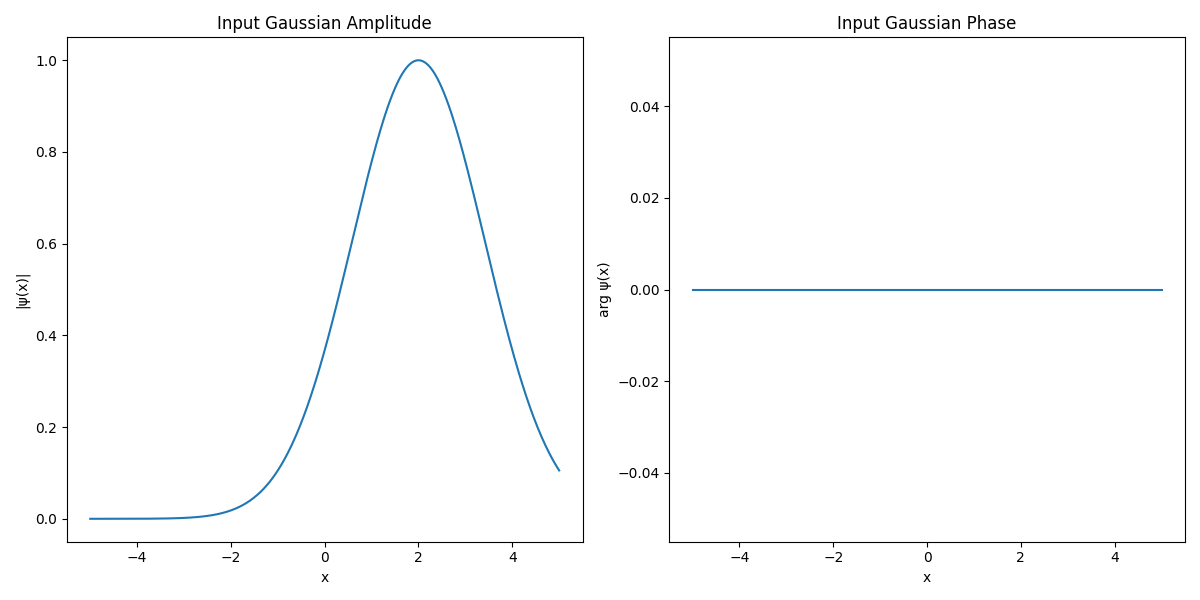

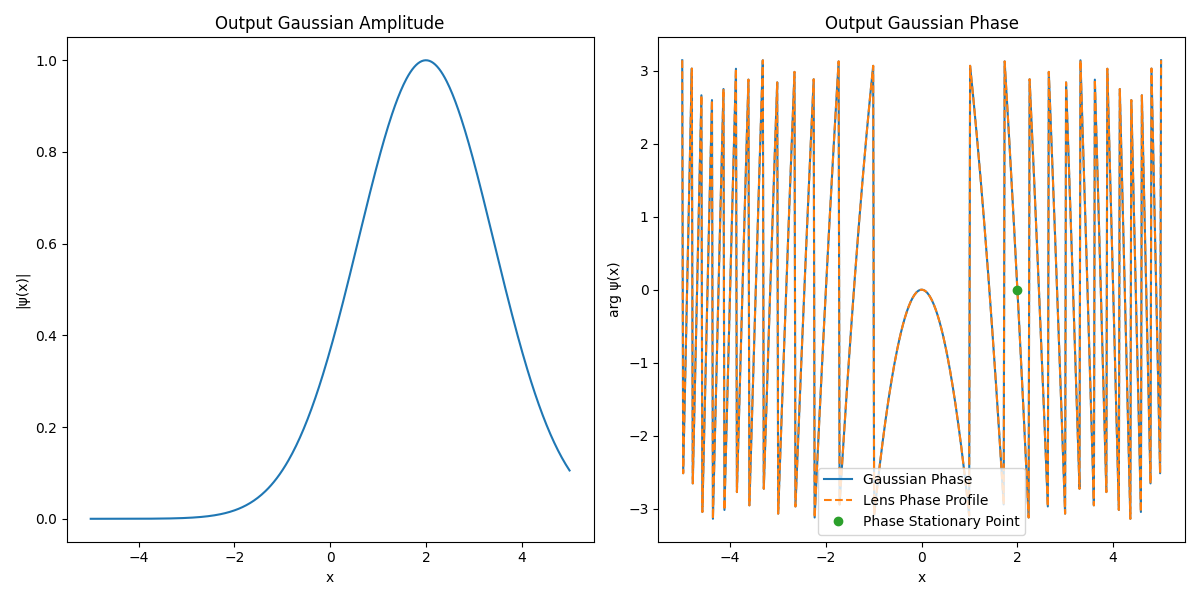

In [82]:
fig, axs = plt.subplots(1, 2, figsize=(12, 6))

axs[0].plot(x_coords, jnp.abs(input_gaussian.field(x_coords)))
axs[0].set_title("Input Gaussian Amplitude")
axs[0].set_xlabel("x")
axs[0].set_ylabel("|ψ(x)|")

axs[1].plot(x_coords, np.angle(input_gaussian.field(x_coords)))
axs[1].set_title("Input Gaussian Phase")
axs[1].set_xlabel("x")
axs[1].set_ylabel("arg ψ(x)")
plt.tight_layout()

fig, axs = plt.subplots(1, 2, figsize=(12, 6))

axs[0].plot(x_coords, jnp.abs(output_gaussian.field(x_coords)))
axs[0].set_title("Output Gaussian Amplitude")
axs[0].set_xlabel("x")
axs[0].set_ylabel("|ψ(x)|")

axs[1].plot(x_coords, np.angle(output_gaussian.field(x_coords)), label='Gaussian Phase')
axs[1].plot(x_coords, np.angle(jnp.exp(1j * k0 * lens(x_coords, f))), linestyle='dashed', label='Lens Phase Profile')
axs[1].plot(output_gaussian.ray_position(), output_gaussian.phase(output_gaussian.ray_position()), 'o', label='Phase Stationary Point')
axs[1].set_title("Output Gaussian Phase")
axs[1].set_xlabel("x")
axs[1].set_ylabel("arg ψ(x)")
plt.legend()
plt.tight_layout()



## Example 2 – Aberrated Lens

Introducing cubic and quartic aberrations shows how the higher-order Taylor terms change the ray's phase and stationary point. The plots compare the Gaussian approximation against the exact lens phase profile.


In [83]:
def aberrated_lens(x, f, a3=0.0, a4=0.0):
    return -0.5 * x ** 2 / f + a3 * x ** 3 + a4 * x ** 4

x_coords = jnp.linspace(-5.0, 5.0, 500)

a3 = 0.01
a4 = 0.001
x0 = 2.0
wavelength = 0.5
k0 = 2.0 * jnp.pi / wavelength  # wavenumber
f = 2.0  # focal length

S0_aberrated_lens = aberrated_lens(x0, f, a3=a3, a4=a4)
S1_aberrated_lens = jax.grad(aberrated_lens)(x0, f, a3=a3, a4=a4)
S2_aberrated_lens = jax.grad(jax.grad(aberrated_lens))(x0, f, a3=a3, a4=a4)


input_gaussian = GaussianRay1D.from_gaussian(
    x=x0,
    dx=0.0,
    InitAmp=1.0,
    InitPhase=0.0,
    BeamWaist=1.0,
    RadiusOfCurvature=jnp.inf,
    k=k0,
)

output_gaussian = input_gaussian.apply_local_phase(
    phi0=S0_aberrated_lens,
    phi1=S1_aberrated_lens,
    phi2=S2_aberrated_lens
)


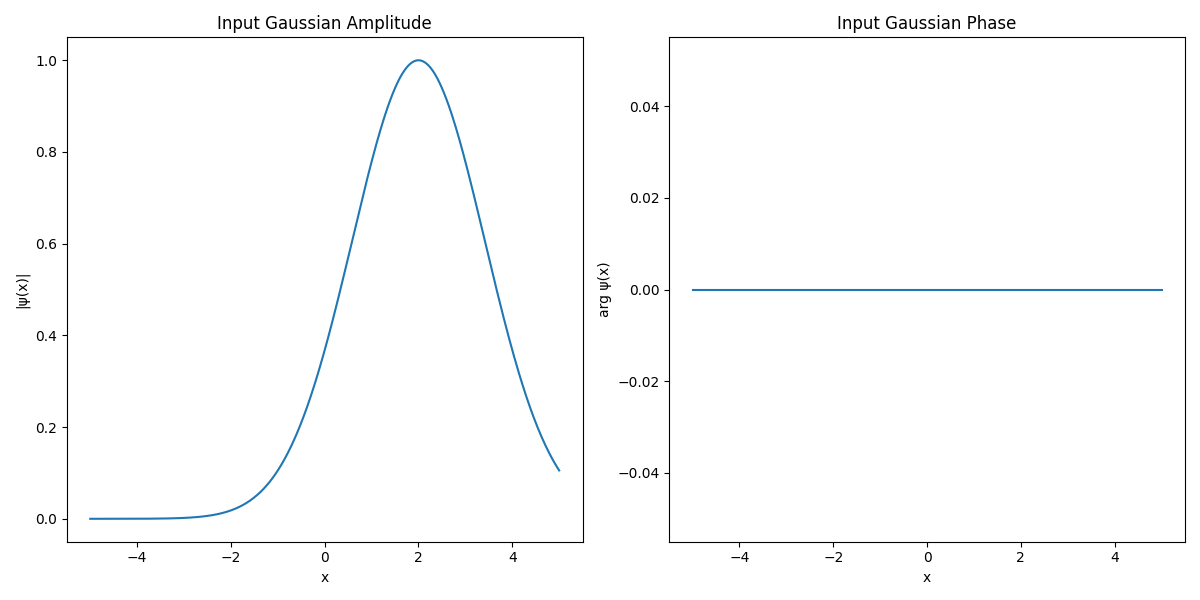

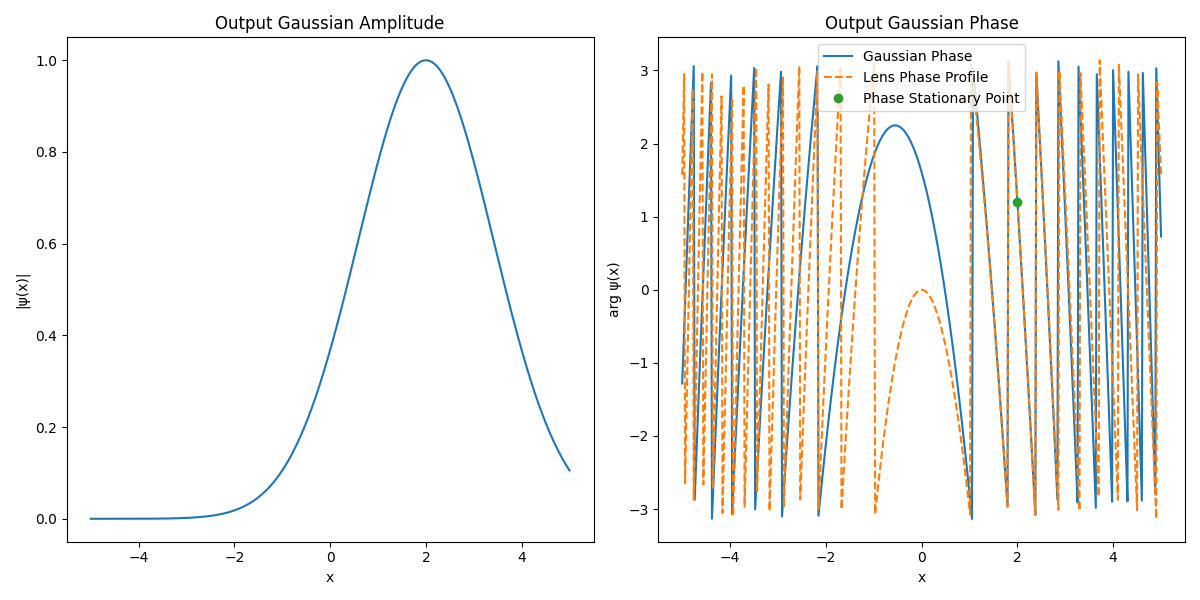

In [84]:
fig, axs = plt.subplots(1, 2, figsize=(12, 6))

axs[0].plot(x_coords, jnp.abs(input_gaussian.field(x_coords)))
axs[0].set_title("Input Gaussian Amplitude")
axs[0].set_xlabel("x")
axs[0].set_ylabel("|ψ(x)|")

axs[1].plot(x_coords, np.angle(input_gaussian.field(x_coords)))
axs[1].set_title("Input Gaussian Phase")
axs[1].set_xlabel("x")
axs[1].set_ylabel("arg ψ(x)")
plt.tight_layout()

fig, axs = plt.subplots(1, 2, figsize=(12, 6))

axs[0].plot(x_coords, jnp.abs(output_gaussian.field(x_coords)))
axs[0].set_title("Output Gaussian Amplitude")
axs[0].set_xlabel("x")
axs[0].set_ylabel("|ψ(x)|")

axs[1].plot(x_coords, np.angle(output_gaussian.field(x_coords)), label='Gaussian Phase')
axs[1].plot(x_coords, np.angle(jnp.exp(1j * k0 * aberrated_lens(x_coords, f, a3=a3, a4=a4))), linestyle='dashed', label='Lens Phase Profile')
axs[1].plot(output_gaussian.ray_position(), output_gaussian.phase(output_gaussian.ray_position()), 'o', label='Phase Stationary Point')
axs[1].set_title("Output Gaussian Phase")
axs[1].set_xlabel("x")
axs[1].set_ylabel("arg ψ(x)")
plt.legend()
plt.tight_layout()



## Example 3 – Half-Edge Aperture

Finally, we fold a smooth aperture edge into the Gaussian via a local log-amplitude Taylor expansion. This highlights how amplitude perturbations shift the ray position and intensity centre.


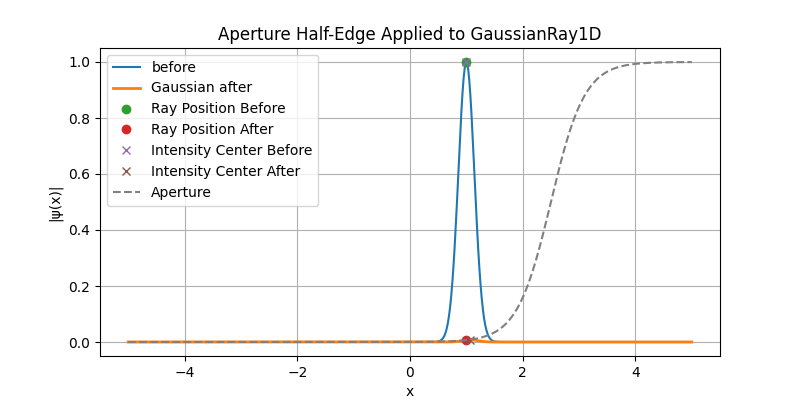

In [85]:
# Sigmoid half-edge amplitude component and helper to apply it to a GaussianRay1D
# Uses existing jax, jnp, jax.grad, GaussianRay1D, x_coords, applied_lens_phase, plt from the notebook.

def sigmoid_edge_profile(x, x_edge=0.0, width=0.5, t_low=0.0, t_high=1.0):
    """Smooth half-edge transmission between t_low and t_high via a sigmoid.
    x may be scalar or array-like (jnp).
    width controls transition sharpness (larger = smoother)."""
    z = (x - x_edge) / (width + 1e-16)
    s = 1.0 / (1.0 + jnp.exp(-z))
    return t_low + (t_high - t_low) * s

def apply_half_edge_to_ray(ray, x_edge=0.0, width=0.5, t_low=0.0, t_high=1.0, eps=1e-12):
    """Fold a smooth half-edge amplitude into the ray by Taylor-expanding log(amplitude)
    about ray.x0 up to quadratic and calling ray.apply_local_amplitude(...).
    Returns the new GaussianRay1D."""
    # scalar function of x for jax differentiation
    def log_amp_scalar(x):
        return jnp.log(sigmoid_edge_profile(x, x_edge=x_edge, width=width, t_low=t_low, t_high=t_high) + eps)

    x0 = float(ray.x0)
    ell0 = float(log_amp_scalar(x0))
    ell1 = float(jax.grad(log_amp_scalar)(x0))
    ell2 = float(jax.grad(jax.grad(log_amp_scalar))(x0))
    return ray.apply_local_amplitude(ell0=ell0, ell1=ell1, ell2=ell2)

edge_x = 2.5
edge_width = 0.3
t_low, t_high = 0.0, 1.0
x0 = 1.0

aperture = sigmoid_edge_profile(x_coords, x_edge=edge_x, width=edge_width, t_low=t_low, t_high=t_high)
input_gaussian = GaussianRay1D.from_gaussian(
    x=x0,
    dx=0.0,
    InitAmp=1.0,
    InitPhase=0.0,
    BeamWaist=0.1,
    RadiusOfCurvature=jnp.inf,
    k=k0,
)


output_gaussian = apply_half_edge_to_ray(
    input_gaussian,
    x_edge=edge_x,
    width=edge_width,
    t_low=t_low,
    t_high=t_high
)

input_amplitude = jnp.abs(input_gaussian.amplitude(x_coords))

plt.figure(figsize=(8, 4))
plt.plot(x_coords, input_amplitude, label="before")
plt.plot(x_coords, jnp.abs(output_gaussian.field(x_coords)), label="Gaussian after", lw=2)
plt.plot(input_gaussian.x0, jnp.abs(input_gaussian.field(input_gaussian.x0)), 'o', label='Ray Position Before')
plt.plot(output_gaussian.x0, jnp.abs(output_gaussian.field(output_gaussian.x0)), 'o', label='Ray Position After')
plt.plot(input_gaussian.intensity_center(), jnp.abs(input_gaussian.field(input_gaussian.intensity_center())), 'x', label='Intensity Center Before')
plt.plot(output_gaussian.intensity_center(), jnp.abs(output_gaussian.field(output_gaussian.intensity_center())), 'x', label='Intensity Center After')
plt.plot(x_coords, aperture, linestyle='--', color='gray', label='Aperture')
plt.xlabel("x")
plt.ylabel("|ψ(x)|")
plt.title("Aperture Half-Edge Applied to GaussianRay1D")
plt.legend()
plt.grid(True)

## Example 4 Propagation in Free Space

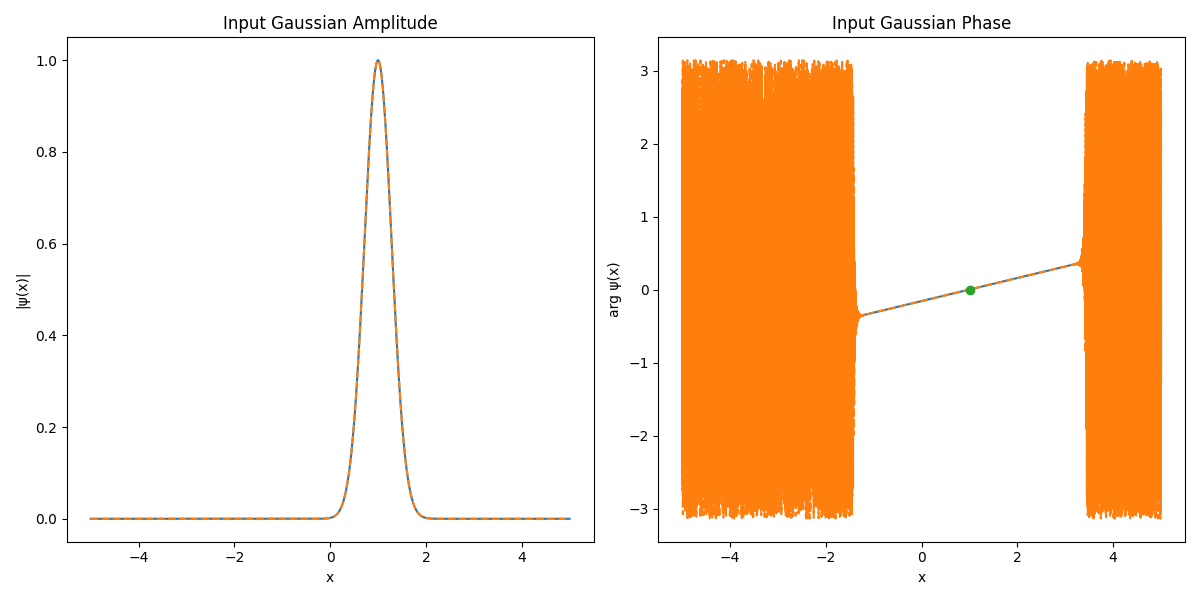

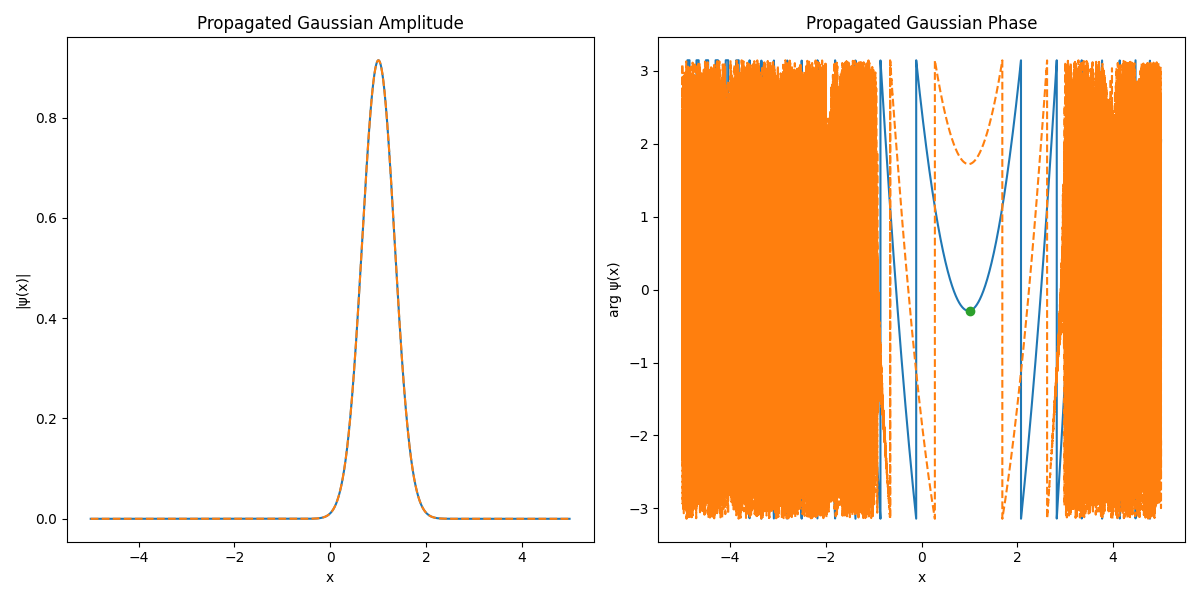

In [86]:
x_coords = jnp.linspace(-5.0, 5.0, 30000)
input_gaussian = GaussianRay1D.from_gaussian(
    x=x0,
    dx=1e-3,
    InitAmp=1.0,
    InitPhase=0.0,
    BeamWaist=0.2,
    RadiusOfCurvature=jnp.inf,
    k=k0,
)

z = 0.66
propagated_gaussian = input_gaussian.propagate(A=1.0, B=z, C=0.0, D=1.0)

L = 10
input_gaussian_fresnel = FresnelPropagator1D(input_gaussian.field(x_coords), L, wavelength, 0)
propagated_gaussian_fresnel = FresnelPropagator1D(input_gaussian.field(x_coords), L, wavelength, z)


fig, axs = plt.subplots(1, 2, figsize=(12, 6))
axs[0].plot(x_coords, jnp.abs(input_gaussian.field(x_coords)))
axs[0].plot(x_coords, jnp.abs(input_gaussian_fresnel), linestyle='dashed', label='Fresnel Input Amplitude')
axs[0].set_title("Input Gaussian Amplitude")
axs[0].set_xlabel("x")
axs[0].set_ylabel("|ψ(x)|")

axs[1].plot(x_coords, np.angle(input_gaussian.field(x_coords)))
axs[1].plot(x_coords, np.angle(input_gaussian_fresnel), linestyle='dashed', label='Fresnel Input Phase')
axs[1].plot(input_gaussian.ray_position(), input_gaussian.phase(input_gaussian.ray_position()), 'o', label='Phase Stationary Point')
axs[1].set_title("Input Gaussian Phase")
axs[1].set_xlabel("x")
axs[1].set_ylabel("arg ψ(x)")
plt.tight_layout()

fig, axs = plt.subplots(1, 2, figsize=(12, 6))
axs[0].plot(x_coords, jnp.abs(propagated_gaussian.field(x_coords)), label='Gaussian Propagated Amplitude')
axs[0].plot(x_coords, jnp.abs(propagated_gaussian_fresnel), linestyle='dashed', label='Fresnel Propagated Amplitude')
axs[0].set_title("Propagated Gaussian Amplitude")
axs[0].set_xlabel("x")
axs[0].set_ylabel("|ψ(x)|")

axs[1].plot(x_coords, np.angle(propagated_gaussian.field(x_coords)), label='Gaussian Phase')
axs[1].plot(x_coords, np.angle(propagated_gaussian_fresnel), linestyle='dashed', label='Fresnel Propagated Phase')
axs[1].plot(propagated_gaussian.ray_position(), propagated_gaussian.phase(propagated_gaussian.ray_position()), 'o', label='Phase Stationary Point')
axs[1].set_title("Propagated Gaussian Phase")
axs[1].set_xlabel("x")
axs[1].set_ylabel("arg ψ(x)")
plt.tight_layout()

## Example 5 Lens Imaging

1.0
z1=0.66, z2=0.66
Overall ABCD matrix:
[[-1.        0.      ]
 [-3.030303 -1.      ]]


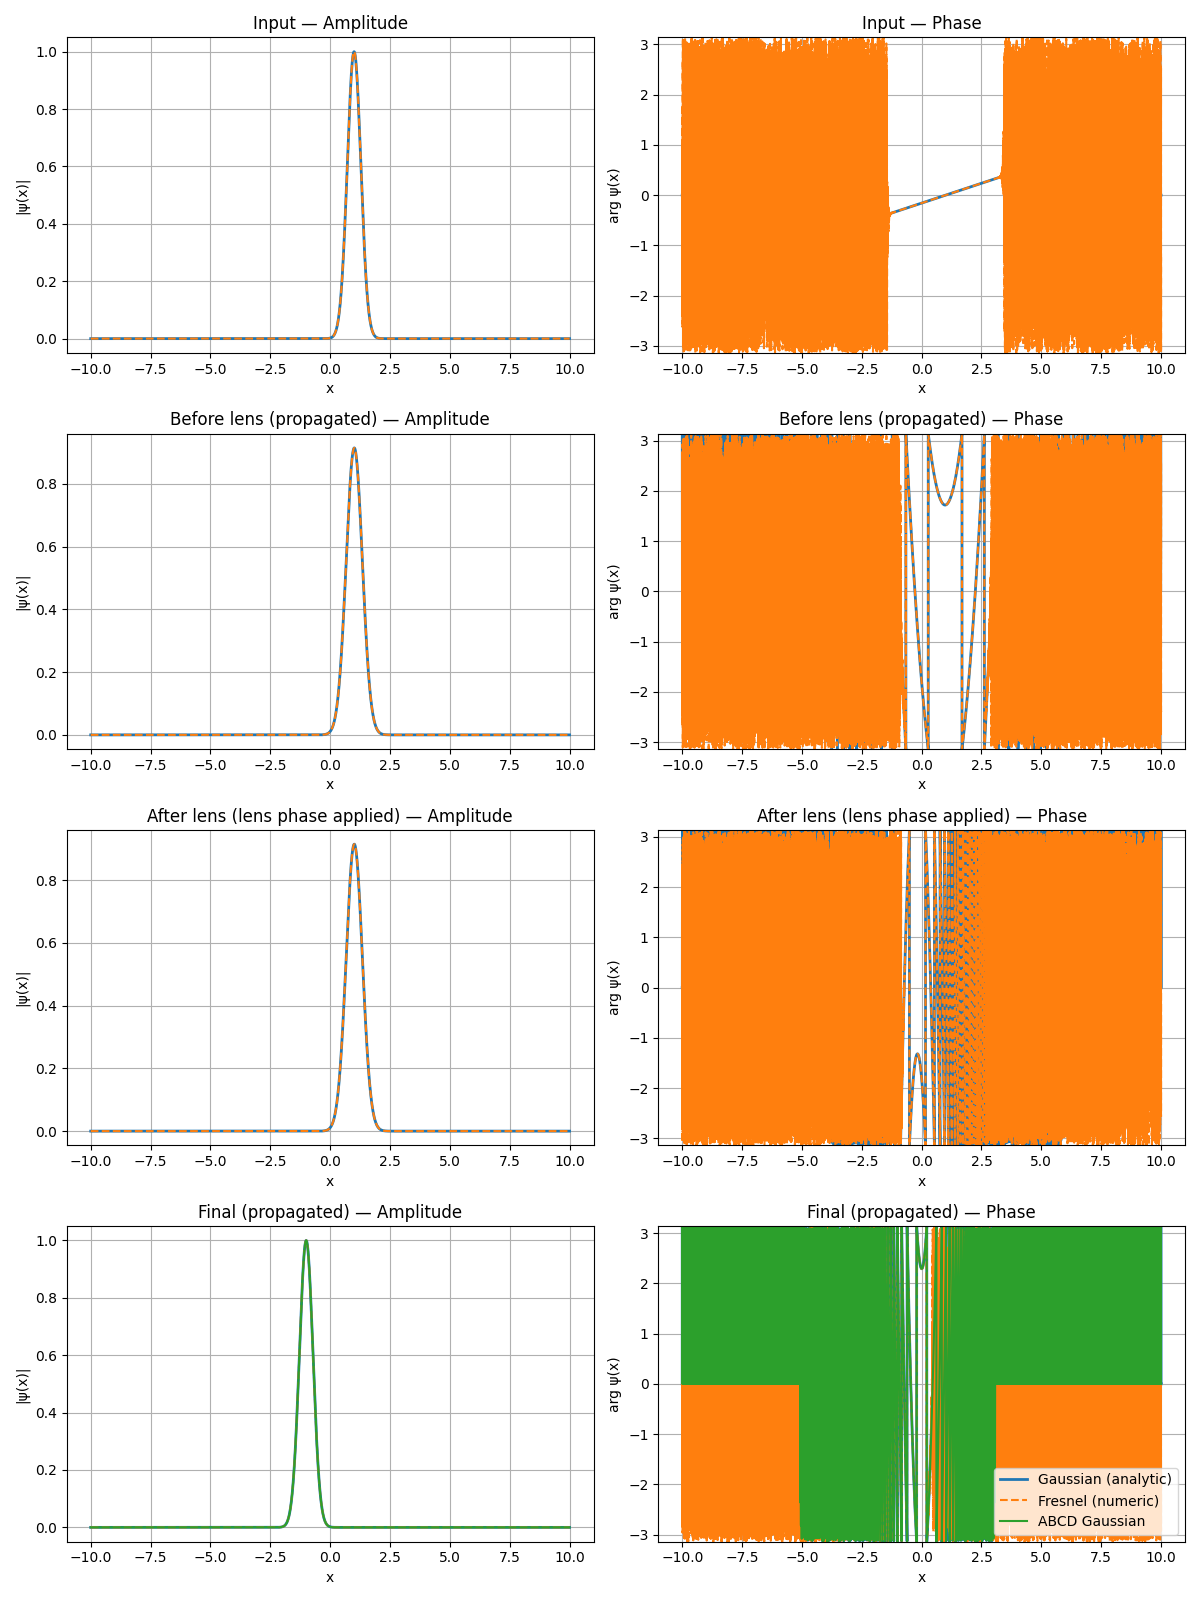

In [87]:
x_coords = jnp.linspace(-10.0, 10.0, 30000)
print(x0)
input_gaussian = GaussianRay1D.from_gaussian(
    x=x0,
    dx=1e-3,
    InitAmp=1.0,
    InitPhase=0.0,
    BeamWaist=0.2,
    RadiusOfCurvature=jnp.inf,
    k=k0,
)

L = x_coords[-1] - x_coords[0]
f = 0.33
M = -1
z1 = f * (1 - 1 / M)
z2 = f * (1 - M)
z1 = abs(z1)
z2 = abs(z2)
print(f"z1={z1}, z2={z2}")
before_lens_gaussian = input_gaussian.propagate(A=1.0, B=z1, C=0.0, D=1.0, L=z1)
after_lens_gaussian = before_lens_gaussian.propagate(A=1.0, B=0.0, C=-1.0/f, D=1.0, L=0.0)
final_gaussian = after_lens_gaussian.propagate(A=1.0, B=z2, C=0.0, D=1.0, L=z2)


ABCD_mat = jnp.array([[1.0, z2], [0.0, 1.0]]) @ jnp.array([[1.0, 0.0], [-1.0/f, 1.0]]) @ jnp.array([[1.0, z1], [0.0, 1.0]])
print("Overall ABCD matrix:")
print(ABCD_mat)

ABCD_gaussian = input_gaussian.propagate(
    A=ABCD_mat[0,0],
    B=ABCD_mat[0,1],
    C=ABCD_mat[1,0],
    D=ABCD_mat[1,1],
    L=z1 + z2
)


fresnel_input_gaussian = FresnelPropagator1D(input_gaussian.field(x_coords), L, wavelength, 0)
fresnel_before_lens = FresnelPropagator1D(fresnel_input_gaussian, L, wavelength, z1)
fresnel_after_lens = fresnel_before_lens * jnp.exp(1j * k0 * lens(x_coords, f))
fresnel_final = FresnelPropagator1D(fresnel_after_lens, L, wavelength, z2)


# create a 4x2 grid so we can include the "Before lens" stage
stages = [
    ("Input", input_gaussian),
    ("Before lens (propagated)", before_lens_gaussian),
    ("After lens (lens phase applied)", after_lens_gaussian),
    ("Final (propagated)", final_gaussian),
]

# corresponding Fresnel fields (must match the order above)
fresnel_fields = [
    fresnel_input_gaussian,
    fresnel_before_lens,
    fresnel_after_lens,
    fresnel_final,
]

fig, axs = plt.subplots(4, 2, figsize=(12, 16))

for i, (label, g) in enumerate(stages):
    axA = axs[i, 0]
    axP = axs[i, 1]

    # Gaussian (analytic) amplitude & phase
    gauss_field = g.field(x_coords)
    axA.plot(x_coords, jnp.abs(gauss_field), label='Gaussian (analytic)', lw=2)
    phi_gauss = np.angle(np.asarray(gauss_field))
    axP.plot(x_coords, phi_gauss, label='Gaussian (analytic)', lw=2)

    # Fresnel (numerical) amplitude & phase (convert to numpy safely)
    fresnel_field = np.asarray(fresnel_fields[i])
    axA.plot(x_coords, np.abs(fresnel_field), linestyle='dashed', label='Fresnel (numeric)')
    axP.plot(x_coords, np.angle(fresnel_field), linestyle='dashed', label='Fresnel (numeric)')

    axA.set_title(f"{label} — Amplitude")
    axA.set_xlabel("x")
    axA.set_ylabel("|ψ(x)|")
    axA.grid(True)

    axP.set_title(f"{label} — Phase")
    axP.set_xlabel("x")
    axP.set_ylabel("arg ψ(x)")
    axP.set_ylim(-np.pi, np.pi)
    axP.grid(True)

axs[3, 0].plot(x_coords, jnp.abs(ABCD_gaussian.field(x_coords)), '-', label="ABCD Gaussian")
axs[3, 1].plot(x_coords, np.angle(ABCD_gaussian.field(x_coords)), '-', label="ABCD Gaussian")
plt.legend()
plt.tight_layout()
plt.show()
